# Load Data

In [1]:
import pandas as pd
import numpy as np
import shap
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import lifetimes as lt
from xgboost import XGBClassifier

In [2]:
# Load data
transactions = pd.read_csv('data/transactions.csv', parse_dates=['transaction_date'])
customers = pd.read_csv('data/customers.csv', parse_dates=['signup_date'])

print(f"Transactions: {len(transactions)} rows")
print(f"There are {len(customers)} customers, but only {transactions['customer_id'].nunique()} who have made transactions")
transactions.head()

Transactions: 46704 rows
There are 3000 customers, but only 2892 who have made transactions


,customer_id,transaction_date,amount
0,C00000,2025-09-10,195.78
1,C00000,2025-09-12,50.87
2,C00000,2025-10-01,133.25
3,C00000,2025-10-16,37.44
4,C00000,2025-10-18,101.95


In [3]:
print("** customers table:")
print(customers.dtypes)
print("\n")
print("** transactions table:")
print(transactions.dtypes)

** customers table:
customer_id                   object
signup_date           datetime64[ns]
true_lifetime_days             int64
dtype: object


** transactions table:
customer_id                 object
transaction_date    datetime64[ns]
amount                     float64
dtype: object


# RFM Analysis

RFM (Recency, Frequency, Monetary) is a framework that summarises each customer's purchase history into 3 dimensions: how recently they bought (R), how often they buy (F), and how much they spend in total (M). Each dimension is scored 1–5 using quantile binning, and the combined score maps to a named segment (e.g. Champions, At Risk, Hibernating).

The analysis date is set to the day after the last recorded transaction (2025-12-31 + 1 day) so recency reflects days since the final observed purchase, not an arbitrary calendar date. Segments are used downstream to prioritise retention outreach — high-recency, high-frequency customers are worth protecting; hibernating customers with low monetary value are lower priority.

In [4]:
# Use the day after the last transaction as the analysis date (aka 01-01-2026)
analysis_date = transactions['transaction_date'].max() + pd.Timedelta(days=1)
print(f"Analysis date: {analysis_date}")

# RFM per customer
rfm = transactions.groupby('customer_id').agg(
    recency=('transaction_date', lambda x: (analysis_date - x.max()).days),
    frequency=('transaction_date', 'count'),
    monetary=('amount', 'sum')        
).reset_index()

rfm.head()

Analysis date: 2026-01-01 00:00:00


,customer_id,recency,frequency,monetary
0,C00000,1,12,1222.85
1,C00001,12,19,1228.46
2,C00002,97,11,910.64
3,C00003,44,4,114.71
4,C00004,109,19,2018.94


In [5]:
rfm_q = rfm.copy()

# use qcut to divide into 5 quantiles
# Recency: more recent is higher score
rfm_q["R_score"] = pd.qcut(
    rfm_q["recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)
# Frequency: higher is better
rfm_q["F_score"] = pd.qcut(
    rfm_q["frequency"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

# Monetary: higher is better
rfm_q["M_score"] = pd.qcut(
    rfm_q["monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

def rfm_segment_rules(rfm_q):
    r = rfm_q['R_score']
    f = rfm_q['F_score']

    # High R, High F
    if r >= 4 and f >= 4:
        return "Champions"

    # Mid R, High F
    if 2 <= r < 4 and f >= 3:
        return "Loyal Customers"

    # Low R, High F
    if r <= 2 and f >= 4:
        return "Cannot Lose Them"

    # Low R, Mid F
    if r <= 2 and 2 <= f <= 4:
        return "At Risk"

    # Low R, Low F
    if r <= 2 and f <= 2:
        return "Hibernating"

    # Mid-low R, Mid F
    if 2 <= r <= 3 and 2 <= f <= 3:
        return "Need Attention"

    # Mid-low R, Low F
    if 2 <= r <= 3 and f <= 2:
        return "About To Sleep"

    # Mid-high/High R, Mid F
    if r >= 3 and 1 <= f <= 3:
        return "Potential Loyalists"

    # Mid-high R, Low F
    if 3 <= r <= 4 and f <= 1:
        return "Promising"

    # High R, Low F
    if r >= 4 and f <= 1:
        return "New Customers"

    return "Others"

rfm_q['segment'] = rfm_q.apply(rfm_segment_rules, axis=1)

rfm_q

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,segment
0,C00000,1,12,1222.85,5,3,4,Potential Loyalists
1,C00001,12,19,1228.46,4,4,4,Champions
2,C00002,97,11,910.64,2,3,4,Loyal Customers
3,C00003,44,4,114.71,3,1,1,About To Sleep
4,C00004,109,19,2018.94,2,4,5,Loyal Customers
...,...,...,...,...,...,...,...,...
2887,C02995,1,15,460.70,5,4,3,Champions
2888,C02996,34,9,638.36,3,3,3,Loyal Customers
2889,C02997,6,16,459.83,4,4,3,Champions
2890,C02998,1,24,1505.03,5,4,5,Champions


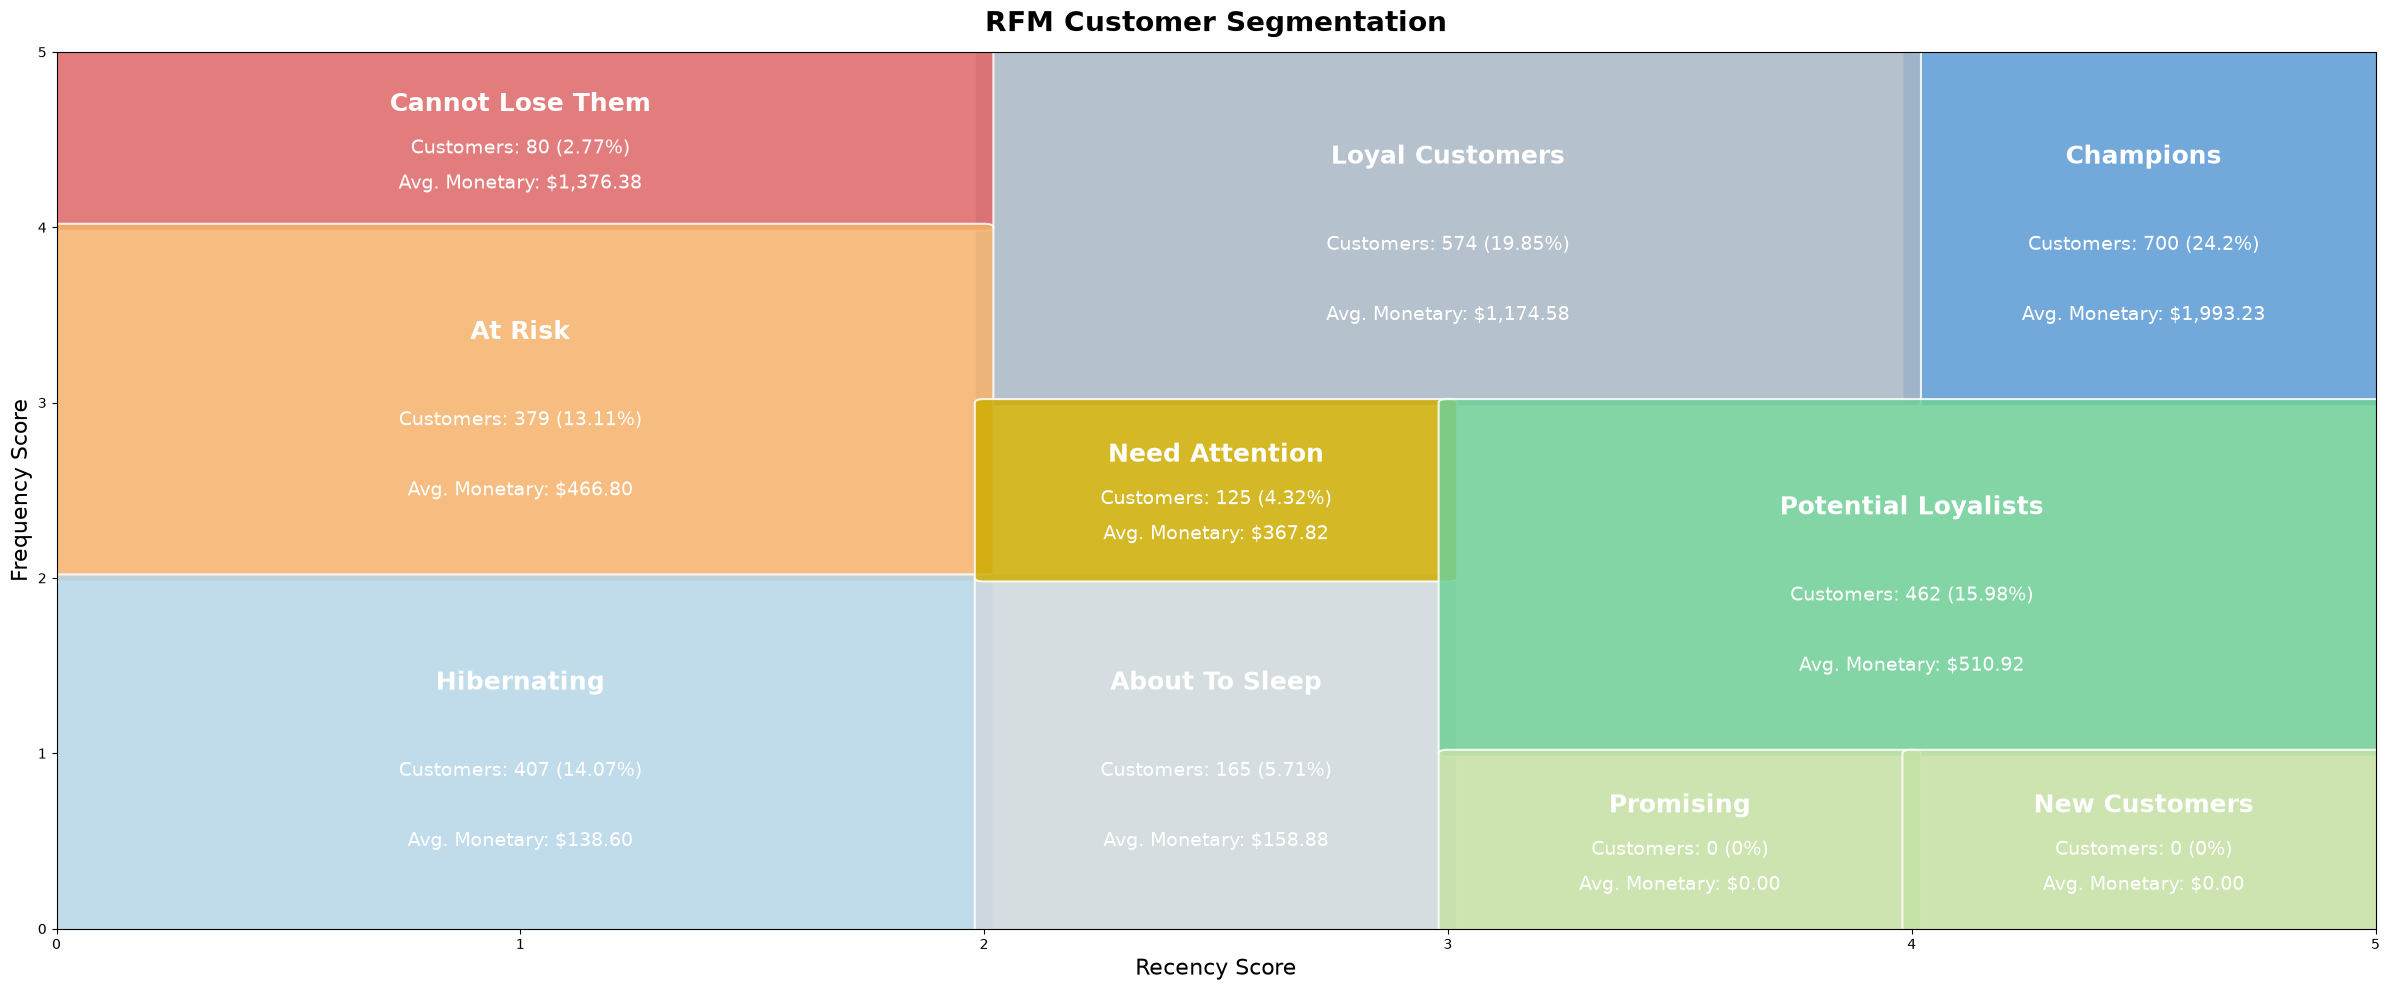

In [6]:
# ── RFM Heatmap Visualization ──

# Compute stats per segment
seg_stats = rfm_q.groupby('segment').agg(
    count=('customer_id', 'count'),
    avg_monetary=('monetary', 'mean')
).reset_index()
total_customers = len(rfm)
seg_stats['pct'] = (seg_stats['count'] / total_customers * 100).round(2)
seg_stats = seg_stats.set_index('segment')

# Grid layout: each segment -> (x, y, width, height) in R x F coordinates
# x = Recency Score (left edge), y = Frequency Score (bottom edge)
grid = {
    'Champions':         (4, 3, 1, 2),
    'Loyal Customers':   (2, 3, 2, 2),
    'Cannot Lose Them':  (0, 4, 2, 1),
    'At Risk':           (0, 2, 2, 2),
    'Hibernating':       (0, 0, 2, 2),
    'About To Sleep':    (2, 0, 1, 2),
    'Need Attention':    (2, 2, 1, 1),
    'Potential Loyalists': (3, 1, 2, 2),
    'Promising':         (3, 0, 1, 1),
    'New Customers':     (4, 0, 1, 1),
}

# Color palette for segments
colors = {
    'Champions':          '#5B9BD5',
    'Loyal Customers':    '#A9B7C6',
    'Cannot Lose Them':   '#E06666',
    'At Risk':            '#F6B26B',
    'Hibernating':        '#B6D7E8',
    'About To Sleep':     '#CFD8DC',
    'Need Attention':     '#CEAD00',
    'Potential Loyalists':'#6FCF97',
    'Promising':          '#C5E1A5',
    'New Customers':      '#C5E1A5',
}

fig, ax = plt.subplots(figsize=(24, 10))

for seg, (x, y, w, h) in grid.items():
    color = colors.get(seg, '#DDDDDD')
    rect = patches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02",
        linewidth=1.5, edgecolor='white', facecolor=color, alpha=0.85
    )
    ax.add_patch(rect)

    # Get stats
    if seg in seg_stats.index:
        count = seg_stats.loc[seg, 'count']
        pct = seg_stats.loc[seg, 'pct']
        avg_m = seg_stats.loc[seg, 'avg_monetary']
    else:
        count, pct, avg_m = 0, 0, 0

    cx, cy = x + w / 2, y + h / 2
    ax.text(cx, cy + h * 0.2, seg, ha='center', va='center',
            fontsize=18, fontweight='bold', color='white')
    ax.text(cx, cy - h * 0.05, f"Customers: {count:,} ({pct}%)",
            ha='center', va='center', fontsize=14, color='white')
    ax.text(cx, cy - h * 0.25, f"Avg. Monetary: ${avg_m:,.2f}",
            ha='center', va='center', fontsize=14, color='white')

ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_xlabel('Recency Score', fontsize=16)
ax.set_ylabel('Frequency Score', fontsize=16)
ax.set_title('RFM Customer Segmentation', fontsize=20, fontweight='bold', pad=15)
ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.grid(False)
ax.set_facecolor('#FAFAFA')
fig.tight_layout()
plt.show()

Hibernating customers make infrequent purchases and haven't bought in a long time, making them at high risk for churn. As a business, it's better to prioritize champions and focus on converting potential loyalists into loyal customers or champions, rather than targeting hibernating customers.

# Churn Classification

Churn is framed as a binary supervised classification problem. The dataset is split at a **cutoff date** of **2025-10-02** (= 2025-12-31 minus a 90-day prediction window):

- **Features** are engineered from all transactions **before** the cutoff — everything except the last 90 days.
- **Churn label** is derived from the **last 90 days** of the dataset (Oct 2 → Dec 31): a customer is labelled `churned = True` if they made no purchase during that window.

This design ensures no future transactions leak into the features. One inherent limitation is right-censoring: any customer who made no purchase between Oct 2 and Dec 31 is labelled churned, even if they would have returned in early 2026. The model treats label-period inactivity as permanent dropout, which slightly overstates true churn.

## Churn Labelling

In [7]:
prediction_window = 90
cutoff_date = pd.Timestamp('2025-12-31') - pd.Timedelta(days=prediction_window)

# function to create churn labels
def create_churn_labels(df, cutoff_date, prediction_window):
    future = df[(df['transaction_date'] > cutoff_date) & (df['transaction_date'] <= cutoff_date + pd.Timedelta(days=prediction_window))]
    # currently active customers during the 90-day prediction window
    active_customers = future['customer_id'].unique()
    labels = (
        df[df["transaction_date"] <= cutoff_date]
        [["customer_id"]]
        .drop_duplicates()
    )
    # churn is True if customer is not in the active_customers list, aka not purchased in the last 90 days
    labels["churn"] = ~labels["customer_id"].isin(active_customers)
    
    return labels.reset_index(drop=True)

churn_labels = create_churn_labels(transactions, cutoff_date, prediction_window)

# check for data imbalance
print(churn_labels['churn'].value_counts())

churn_labels.head()

churn
True     1167
False    1097
Name: count, dtype: int64


,customer_id,churn
0,C00000,False
1,C00001,False
2,C00002,True
3,C00004,True
4,C00006,False


--> Since churn is roughly split between True and False (about 50/50), class imbalance is not a major concern for this dataset

In [8]:
# feature engineering for churn classification
def create_churn_features(df, cutoff_date):
    hist = df[df["transaction_date"] <= cutoff_date]

    agg = hist.groupby('customer_id').agg(
        # rfm
        recency=('transaction_date', lambda x: (cutoff_date - x.max()).days),
        frequency=('transaction_date', 'count'),
        monetary=('amount', 'sum'),
        # change in activity trend
        freq_30d = ('transaction_date', lambda x: (x >= cutoff_date - pd.Timedelta(days=30)).sum()),
        freq_90d = ('transaction_date', lambda x: (x >= cutoff_date - pd.Timedelta(days=90)).sum()),
        amount_30d = ('amount', lambda s: s[hist.loc[s.index, 'transaction_date'] >= cutoff_date - pd.Timedelta(days=30)].sum()),
        amount_90d = ('amount', lambda s: s[hist.loc[s.index, 'transaction_date'] >= cutoff_date - pd.Timedelta(days=90)].sum()),
        freq_past_90d_to_cutoff = ('transaction_date', lambda x: (x >= cutoff_date - pd.Timedelta(days=90)).sum()),
        freq_past_270d_to_180d = ('transaction_date', lambda x: ((x >= cutoff_date - pd.Timedelta(days=270)) & (x < cutoff_date - pd.Timedelta(days=180))).sum()),
        # gap between transactions
        max_gap=('transaction_date', lambda x: x.sort_values().diff().dt.days.max())
        )
        
    agg['freq30/90'] = agg['freq_30d'] / (agg['freq_90d'] + 1e-6)
    agg['amount30/90'] = agg['amount_30d'] / (agg['amount_90d'] + 1e-6)
    # compare total # transactions from 90d to cutoff vs from 270d to 180d
    agg['subtraction_90_270'] = agg['freq_past_90d_to_cutoff'] - agg['freq_past_270d_to_180d']
    
    return agg.reset_index()

features = create_churn_features(transactions, cutoff_date)

data = features.merge(churn_labels, on='customer_id')

In [9]:
train = data[data['customer_id'].isin(data['customer_id'].sample(frac=0.7, random_state=42))]
test = data[~data['customer_id'].isin(train['customer_id'])]

X_train = train.drop(columns=['customer_id', 'churn'])
y_train = train['churn'].astype(int)
X_test = test.drop(columns=['customer_id', 'churn'])
y_test = test['churn']

## Light GBM

LightGBM is a gradient-boosted decision tree (GBDT) model well-suited for tabular data. It builds an ensemble of shallow trees sequentially, where each tree corrects the residual errors of the previous one.

The model is trained with `n_estimators=100`, `learning_rate=0.05`, and `max_depth=5`. Two metrics are tracked: AUC (ROC) and PR-AUC


 **PR-AUC** — Measures whether the model's churn predictions are accurate
  (Precision) and complete (Recall). Ignores non-churners entirely, making it
  a more honest indicator of real-world performance when churners are rare.

The model achieves **AUC = 0.94** and **PR-AUC = 0.96** on the test set, indicating strong discriminative power.

In [11]:
lgbm = LGBMClassifier(
    objective='binary',
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    metric='average_precision',
    verbose=-1
)

lgbm.fit(X_train, y_train)

def evaluate(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    return {
        "AUC": roc_auc_score(y, proba),
        "PR_AUC": average_precision_score(y, proba)
    }


print(evaluate(lgbm, X_test, y_test))

{'AUC': 0.941126354805277, 'PR_AUC': 0.9594526997658412}


## XG Boost

XGBoost is trained with the same hyperparameters (`n_estimators=100`, `learning_rate=0.05`, `max_depth=5`) to serve as a direct benchmark against LightGBM. Both are gradient-boosted tree ensembles; the key difference is that LightGBM grows trees leaf-wise while XGBoost grows them level-wise, which can lead to different bias-variance tradeoffs.

XGBoost achieves **AUC = 0.937** and **PR-AUC = 0.956** — marginally below LightGBM

In [12]:
xgb = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='aucpr'
)

xgb.fit(X_train, y_train)


print(evaluate(xgb, X_test, y_test))


{'AUC': 0.9365591020078347, 'PR_AUC': 0.9561626156514509}


## Confusion Matrix for LGBM

LightGBM outputs a churn probability between 0 and 1. The default decision threshold of 0.5 is not always optimal — lowering it flags more customers as churners (higher recall, lower precision) and raising it does the opposite.

Here, the threshold is tuned by sweeping values from 0.1 to 0.9 and picking the one that maximises **F1 score**, which balances precision and recall equally. The optimal threshold is **0.34** with an F1 of **0.88**, meaning the model calls "churn" at a relatively low confidence level — appropriate when missing a churner is costlier than a false alarm.

Best F1 threshold: 0.340  →  F1: 0.883


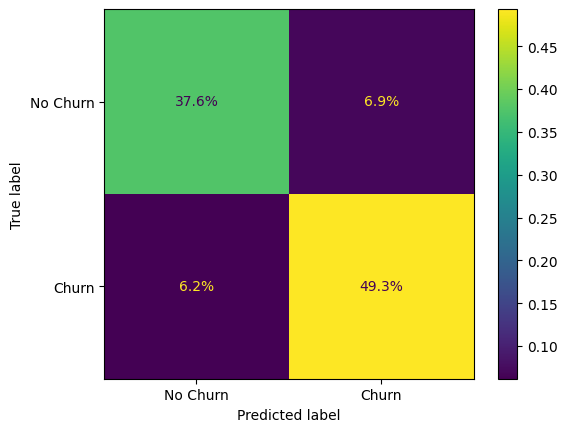

In [12]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, (lgbm.predict_proba(X_test)[:,1] >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best F1 threshold: {best_threshold:.3f}  →  F1: {max(f1_scores):.3f}")
####

lgbm_pred = (lgbm.predict_proba(X_test)[:,1] >= best_threshold).astype(int)
# display matrix
cm = confusion_matrix(y_test, lgbm_pred, normalize='all')
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn']).plot(values_format='.1%')
plt.show()


# Feature Explanation with SHAP

SHAP (SHapley Additive exPlanations) quantifies each feature's contribution to a prediction. `TreeExplainer` computes exact SHAP values efficiently for tree-based models like LightGBM.

The **summary plot** shows global feature importance — which features drive churn predictions across the entire test set. **Force plots** below show local explanations — how individual features push a specific customer's score above or below the baseline.

/Users/hoangntmbee/Downloads/survival_analysis/venv/lib/python3.14/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


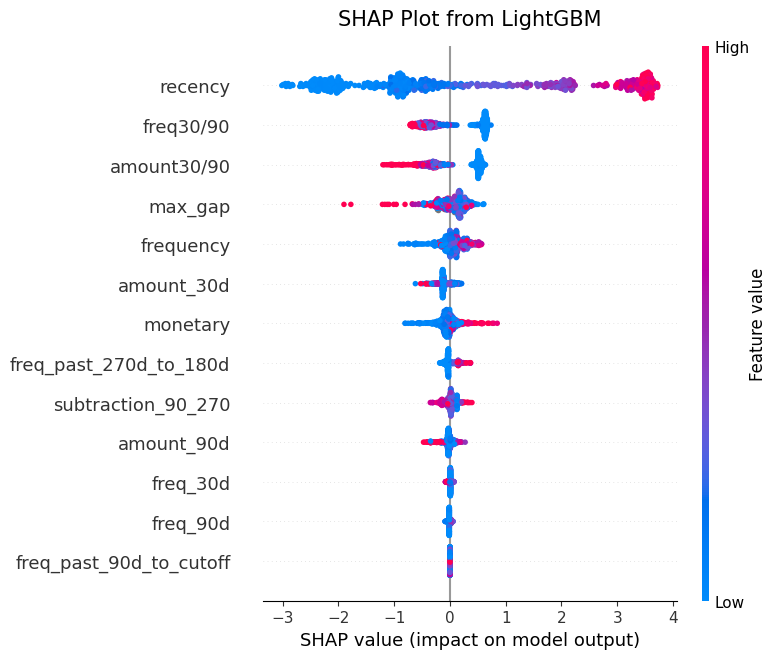

In [13]:
explainer = shap.TreeExplainer(lgbm)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Plot from LightGBM", size=15, pad=15)
plt.tight_layout()
plt.show()

In [25]:
X_test

,recency,frequency,monetary,freq_30d,freq_90d,amount_30d,amount_90d,freq_past_90d_to_cutoff,freq_past_270d_to_180d,max_gap,freq30/90,amount30/90,subtraction_90_270
1,21,11,620.79,1,5,35.45,394.12,5,1,40.0,0.200000,0.089947,4
4,28,1,20.20,1,1,20.20,20.20,1,0,NaN,0.999999,1.000000,1
11,2,11,273.14,6,11,164.78,273.14,11,0,16.0,0.545454,0.603280,11
16,48,28,1302.07,0,12,0.00,393.50,12,4,22.0,0.000000,0.000000,8
17,16,7,44.23,1,6,4.95,34.19,6,0,25.0,0.166667,0.144779,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,5,10,798.75,4,9,352.89,709.28,9,0,29.0,0.444444,0.497533,9
2246,5,10,618.78,5,10,262.69,618.78,10,0,22.0,0.500000,0.424529,10
2248,54,8,1295.82,0,4,0.00,717.80,4,0,59.0,0.000000,0.000000,4
2256,14,4,223.44,3,4,172.46,223.44,4,0,13.0,0.750000,0.771840,4


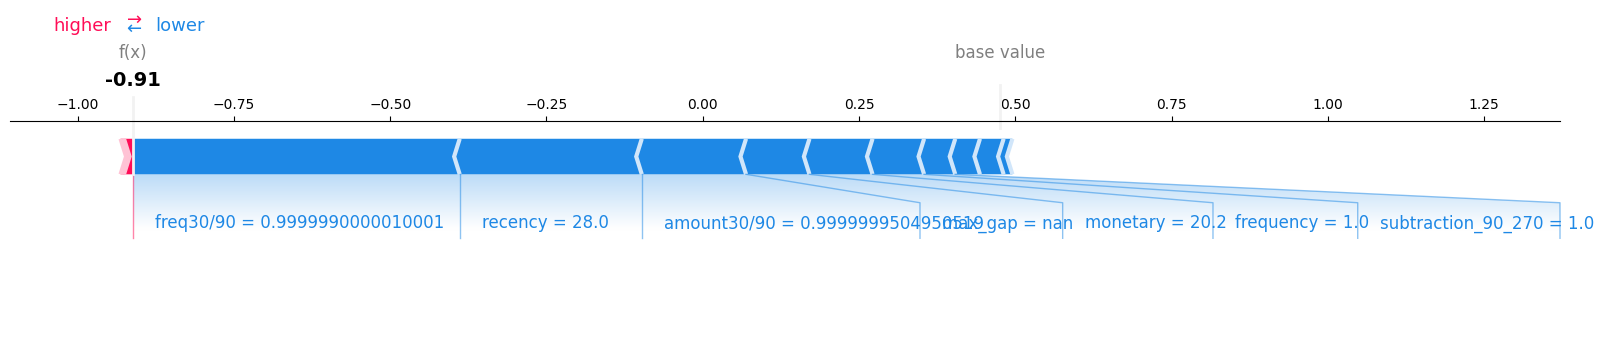

In [14]:
idx=1 # y_test: no churn

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx],
    matplotlib=True
)

**log-odds** = -0.91 → Churn Probability = 28.70%
 
$$p = \frac{1}{1 + e^{-(\text{log-odds})}} = \frac{1}{1 + e^{0.91}} = \frac{1}{1 + 2.484} = \frac{1}{3.484} \approx 0.287$$

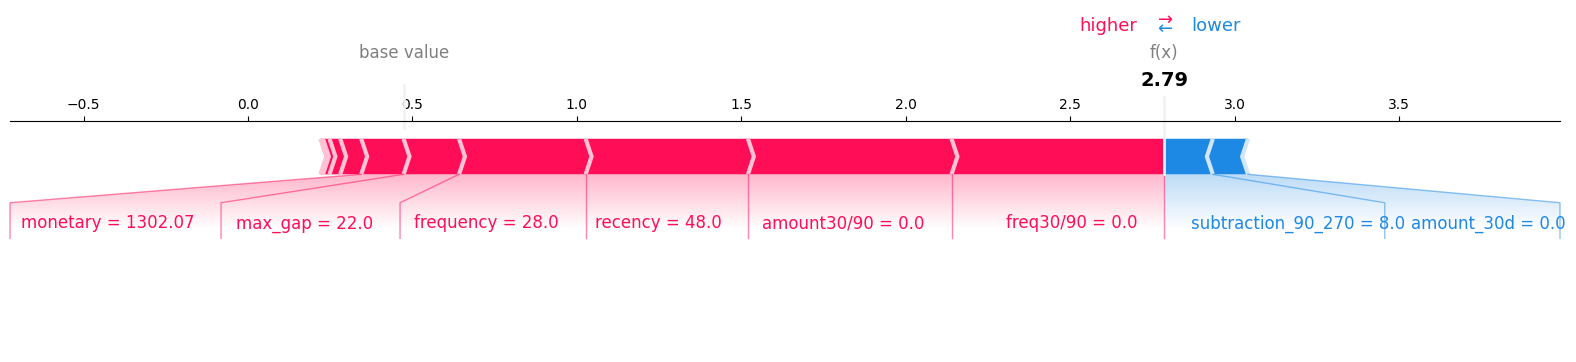

In [15]:
idx=3 # y_test: churn

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx],
    matplotlib=True
)

**log-odds** = 2.79 → Churn Probability = 94.21%

$$p = \frac{1}{1 + e^{-(\text{log-odds})}} = \frac{1}{1 + e^{-2.79}} = \frac{1}{1 + 0.061} = \frac{1}{1.061} \approx 0.942$$

# BG-NBD + Gamma-Gamma

The BG/NBD + Gamma-Gamma framework models each customer's future behaviour using only their transaction history — no demographic or product features required. It answers two questions: *Is this customer still active?* and *How much will they spend?*

The same `cutoff_date` from the churn model is reused here to split the data into a **calibration period** (transactions before the cutoff, used to fit the model) and a **holdout period** (transactions after, used to validate predictions).

**Dropout rate — Beta-Geometric (BG):**

**Beta(a, b)** captures how dropout probability varies across customers; **Geometric** models when a specific customer drops out. Together they produce **P(alive)** — the probability a customer is still active at a given point in time.

**Purchase rate — NBD + Gamma-Gamma:**

**Gamma(r, α) + Poisson** (the NBD) predicts how many purchases a customer will make in a future window. **Gamma-Gamma** then estimates the average transaction value. Multiplying the two gives **CLV**.

## Lifetime Summary Dataframe

In [16]:
lifetime_df = (
    lt.utils.summary_data_from_transaction_data(
        transactions,
        customer_id_col='customer_id',
        datetime_col='transaction_date',
        monetary_value_col='amount', # for Gamma Gamma Fitter later
        observation_period_end=cutoff_date,  # to compare with the classification model
        freq='D'
    )
)

lifetime_df.head()

,frequency,recency,T,monetary_value
customer_id,,,,
C00000,2.0,21.0,22.0,92.060000
C00001,9.0,178.0,199.0,61.631111
C00002,9.0,37.0,43.0,86.307778
C00004,17.0,98.0,116.0,109.965882
C00006,0.0,0.0,28.0,0.000000


- frequency: Number of repeat transactions (first purchase excluded)
- recency: Time between first and last purchase within the calibration period (not the same as RFM)
- T (age): Time from first purchase to the end of the calibration period

## BG Fitting and P-alive chart

The **BetaGeoFitter** is fitted on three columns from the lifetime summary: `frequency` (repeat transactions), `recency` (time between first and last purchase), and `T` (total observation time). The `penalizer_coef` adds regularisation to avoid overfitting on customers with very few transactions.

Once fitted, the model can estimate **P(alive)** — the probability that a customer is still an active buyer — for any customer at any point in time.

In [17]:
# Beta Geometric Fitter (BG-NBD)
bg = lt.BetaGeoFitter(penalizer_coef=0.001)
bg.fit(
    frequency=lifetime_df['frequency'],
    recency=lifetime_df['recency'],
    T=lifetime_df['T']
)

print(bg.summary)



            coef  se(coef)  lower 95% bound  upper 95% bound
r       1.843978  0.071687         1.703471         1.984485
alpha  16.111618  0.699011        14.741556        17.481679
a       0.403398  0.022780         0.358750         0.448047
b       4.332786  0.285393         3.773414         4.892157


The P(alive) chart starts from the customer's **first transaction date** and shows how the estimated probability of being active evolves over time. The probability rises after each observed purchase and gradually declines during periods of inactivity. Red dashed lines mark each purchase event.

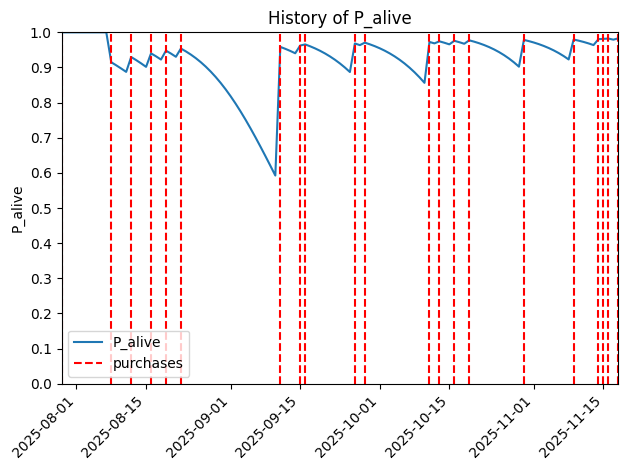

In [18]:
# p-alive chart
from lifetimes import plotting

id = 'C01329'
customer_transactions = (
    transactions[transactions['customer_id'] == id]
    .assign(transaction_date=lambda x: x['transaction_date'].astype('datetime64[ns]'))
)

ax = plotting.plot_history_alive(
    bg,
    t=90,
    transactions=customer_transactions,
    datetime_col='transaction_date'
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

## Gamma-Gamma Fitting and CLV Prediction

The **Gamma-Gamma model** estimates the expected average transaction value per customer. It assumes transaction value is **independent of purchase frequency** — a customer's spending per order doesn't change based on how often they buy.

The model is fitted only on customers with `monetary_value > 0`, since customers with no recorded spend can't be used to estimate an average order value. It produces `expected_avg_order_value` for each qualifying customer.

For the 3-month CLV, both models are used. The Gamma-Gamma fitter calls the BG/NBD model internally to predict expected purchase count over the horizon, then multiplies by expected average order value and applies a monthly discount rate:

> `CLV_3M` ≈ E[purchases over 3M | BG/NBD] × E[avg order value | Gamma-Gamma] × discount factor

A separate BG/NBD call (`bg.predict(t=90, ...)`) also stores the raw purchase count prediction as `predicted_purchases_3M`, which is used independently in the payback model.

In [19]:
# Gamma Gamma Fitter 
gg = lt.GammaGammaFitter(penalizer_coef=0.01)

lifetime_df_ggf = lifetime_df[lifetime_df['monetary_value'] > 0]

gg.fit(
    frequency=lifetime_df_ggf['frequency'],
    monetary_value=lifetime_df_ggf['monetary_value']
)

lifetime_df.loc[lifetime_df_ggf.index, 'expected_avg_order_value'] = (
    gg.conditional_expected_average_profit(
        lifetime_df_ggf['frequency'],
        lifetime_df_ggf['monetary_value']
    )
)

# prediction of purchase count in next 3 months
lifetime_df['predicted_purchases_3M'] = bg.predict(
    t=90,
    frequency=lifetime_df['frequency'],
    recency=lifetime_df['recency'],
    T=lifetime_df['T']
)


lifetime_df['CLV_3M'] = gg.customer_lifetime_value(
    bg,
    lifetime_df_ggf['frequency'],
    lifetime_df_ggf['recency'],
    lifetime_df_ggf['T'],
    lifetime_df_ggf['monetary_value'],
    time=3, # 3 months
    discount_rate=0.01, # 1% discount rate
    freq='D'
)

lifetime_df = lifetime_df.sort_values(by='CLV_3M', ascending=False)

lifetime_df.tail(2000)

,frequency,recency,T,monetary_value,expected_avg_order_value,predicted_purchases_3M,CLV_3M
customer_id,,,,,,,
C01329,10.0,61.0,65.0,74.235000,75.219607,10.738044,792.292971
C01022,1.0,6.0,14.0,132.420000,148.150269,5.414626,787.123783
C00701,9.0,52.0,54.0,69.410000,70.461351,11.300068,781.064273
C00011,5.0,32.0,33.0,80.036000,82.116504,9.690950,780.744510
C02010,16.0,85.0,86.0,58.223125,58.755482,13.504670,778.268270
...,...,...,...,...,...,...,...
C02935,0.0,0.0,195.0,0.000000,NaN,0.750127,NaN
C02954,0.0,0.0,17.0,0.000000,NaN,4.048224,NaN
C02974,0.0,0.0,117.0,0.000000,NaN,1.161573,NaN


## Visualize transaction amount distribution with Gamma

The Gamma-Gamma model parameterises transaction values with a Gamma distribution. After fitting, the parameters `p` and `v` define the shape and scale of that distribution. Sampling 100k values from it and plotting the KDE shows the implied spend pattern.

The **Y-axis (Density)** is not a probability or a count — it is a probability density. The key rule: **the total area under the curve = 1**, representing 100% of all transactions. A taller region means more transactions fall there; a flatter tail means fewer do. The probability of a transaction landing in any range is the *area* under the curve between those two points, not the height.

From this plot: most orders cluster between $0–$25 (the bulk of the area), with a long right tail toward $70 representing rare high-value transactions.

This plot is a sanity check: if the shape matches the observed transaction amount distribution, the model is capturing real spend behaviour correctly.

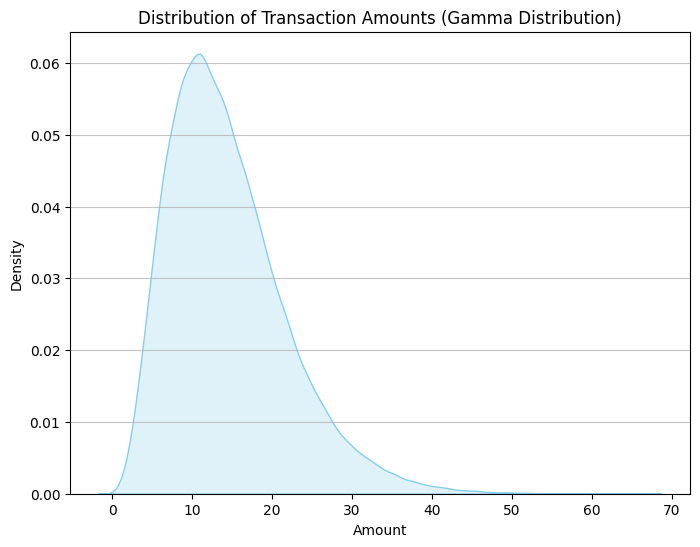

In [20]:
p, q, v = gg.params_

amount_dist = np.random.gamma(shape=p, scale=v, size=100000)

plt.figure(figsize=(8, 6))
sns.kdeplot(amount_dist, fill=True, color='skyblue')
plt.title('Distribution of Transaction Amounts (Gamma Distribution)')
plt.xlabel('Amount')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Survival Analysis

**CoxPH (Cox Proportional Hazards)** models *when* a customer is likely to churn, using their transaction history (`num_transactions`, `avg_amount`, `tenure`) to give each customer a personalised survival curve.

Three key columns are derived from the data:

- **`tenure`** = `cutoff_date` (2025-10-02) − first transaction date — e.g. how long the customer was observed before the cutoff
- **`true_lifetime_days`** = ground-truth total lifetime duration from `customers.csv` — used as the duration column in Cox
- **`residual_days`** = `true_lifetime_days` − `tenure` — how many days of lifetime remain after the cutoff

**Event flag:** a customer is marked `event = 1` (churned) if their `residual_days` is less than the maximum observable window; otherwise `event = 0` (right-censored — still active at the end of the data).

**Left truncation:** customers who churned *before* the cutoff are unobservable at analysis time and are dropped. The `entry_col='tenure'` parameter in the Cox fit corrects for this selection bias — it tells the model that each customer was only at risk from the moment they first transacted, not from day zero.

In [21]:
hist = transactions[transactions['transaction_date'] <= cutoff_date]

survival_df = hist.groupby('customer_id').agg(
    first_txn_date=('transaction_date', 'min'),
    num_transactions=('transaction_date', 'count'),
    avg_amount=('amount', 'mean')
).reset_index()

survival_df['tenure'] = (cutoff_date - survival_df['first_txn_date']).dt.days

survival_df = survival_df.merge(customers[['customer_id', 'true_lifetime_days']], on='customer_id', how='left')

survival_df['residual_days'] = survival_df['true_lifetime_days'] - survival_df['tenure']

observation_end = transactions['transaction_date'].max()
max_possible_residual = (observation_end - survival_df['first_txn_date']).dt.days - survival_df['tenure']
survival_df['event'] = (survival_df['residual_days'] < max_possible_residual).astype(int)

# Remove customers who churned before the cutoff (true lifetime days < tenure)
# entry_col='tenure' in the CPH fit corrects for this selection statistically
n_before = len(survival_df)
survival_df = survival_df[survival_df['residual_days'] > 0].copy()
print(f"Dropped {n_before - len(survival_df)} customers who churned before cutoff (unobservable)")

# Drop helper columns; KEEP true_lifetime_days as duration_col and tenure as entry_col
survival_df = survival_df.drop(columns=['first_txn_date', 'residual_days'])

print(f"Shape: {survival_df.shape}")
print(f"Event rate: {survival_df['event'].mean():.2%}")
display(survival_df.head())

Dropped 938 customers who churned before cutoff (unobservable)
Shape: (1326, 6)
Event rate: 46.00%


,customer_id,num_transactions,avg_amount,tenure,true_lifetime_days,event
0,C00000,3,126.633333,22,204,0
1,C00001,11,56.435455,199,365,0
2,C00002,11,82.785455,43,48,1
4,C00006,1,20.200000,28,117,1
5,C00007,5,116.926000,52,321,0


In [22]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()
cph.fit(
    survival_df.drop(columns=['customer_id']),
    duration_col='true_lifetime_days',
    event_col='event',
    # left truncation to avoid survival bias
    entry_col='tenure'
)
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1326 total observations, 716 right-censored observations>
             duration col = 'true_lifetime_days'
                event col = 'event'
                entry col = 'tenure'
      baseline estimation = breslow
   number of observations = 1326
number of events observed = 610
   partial log-likelihood = -3823.63
         time fit was run = 2026-04-28 02:29:26 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
num_transactions  0.01      1.01      0.00            0.00            0.02                1.00                1.02
avg_amount        0.00      1.00      0.00           -0.00            0.00                1.00                1.00

                  cmp to    z      p  -log2(p)
covariate                                     
num_transactions    0.00 3.13 <0.005      9.15
avg_amount          0.00 1.00   0.32      1.66
---
Concordance = 0.41
Partial AIC = 7651.25
log-likelihood ratio test = 9.85 on 2 df
-log2(p) of ll-ratio test = 7.10

The survival analysis chart below shows the estimated probability that a customer remains active after the cutoff date, conditional on having already survived up to the cutoff (i.e., left truncation is applied). The curve represents a forward-looking survival function from the cutoff point onward.

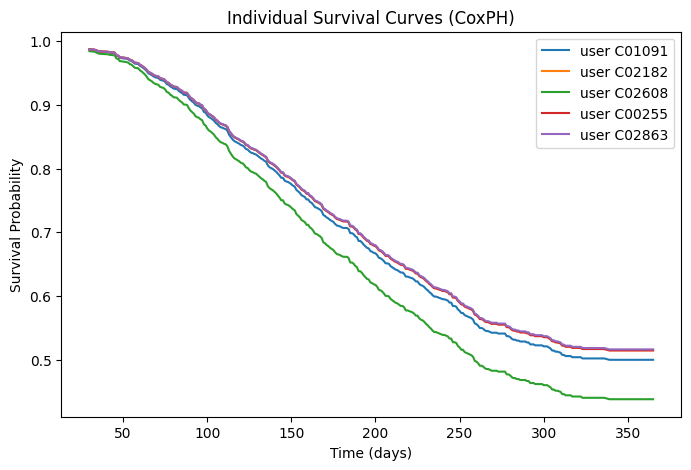

In [23]:
sample_users = survival_df.sample(5, random_state=1)

plt.figure(figsize=(8, 5))

for _, row in sample_users.iterrows():
    surv_fn = cph.predict_survival_function(row[['num_transactions', 'avg_amount', 'tenure']].to_frame().T)
    plt.plot(surv_fn.index, surv_fn.values.flatten(), label=f"user {(row.customer_id)}")

plt.title("Individual Survival Curves (CoxPH)")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

## Cumulative NPV

`get_payback_df` builds a month-by-month table that combines all three models into a single expected value. For each future month:

1. **Monthly Profit** — BG/NBD predicted purchases × Gamma-Gamma average order value
2. **Avg Expected Monthly Profit** — Monthly Profit × Cox survival probability (scales down profit by the chance the customer is still active)
3. **NPV** — Avg Expected Monthly Profit discounted by `(1 + monthly_IRR)^month` to convert future cash flows into today’s value
4. **Cumulative NPV** — running total of all discounted months so far

The result answers: *“If we retain this customer, what is their expected value to us over the next N months — accounting for the risk they churn and the time value of money?”*

In [ ]:
# Business-level assumption — only the discount rate is external; profit is derived per customer
ANNUAL_IRR: float = 0.10


def get_customer_profile(customer_id: str) -> pd.DataFrame:
    """Derive CoxPH inputs from transaction history for a given customer."""
    hist = transactions[
        (transactions['customer_id'] == customer_id) &
        (transactions['transaction_date'] <= cutoff_date)
    ]
    if hist.empty:
        raise ValueError(f"No transactions found for customer '{customer_id}' up to cutoff date.")

    first_txn = hist['transaction_date'].min()
    profile = pd.DataFrame({
        'num_transactions': [len(hist)],
        'avg_amount':       [hist['amount'].mean()],
        'tenure':           [(cutoff_date - first_txn).days],
    })
    return profile


def get_monthly_profit(customer_id: str, num_months: int) -> float:
    """
    Estimate monthly profit using Gamma-Gamma expected order value and
    BG/NBD predicted purchase rate (both fitted on data up to cutoff_date).

    monthly_profit = expected_avg_order_value × (predicted_purchases_3M / 3)
    """
    row = lifetime_df.loc[lifetime_df.index == customer_id]
    if row.empty or pd.isna(row['expected_avg_order_value'].iloc[0]):
        # fallback for one-time buyers excluded from Gamma-Gamma fit
        hist = transactions[
            (transactions['customer_id'] == customer_id) &
            (transactions['transaction_date'] <= cutoff_date)
        ]
        return float(hist['amount'].mean())

    avg_order_value = float(row['expected_avg_order_value'].iloc[0])
    
    purchases_per_month = list()
    for n in range(1, num_months+1):
        monthly_purchases = bg.predict(
            t=n*30,
            frequency=row['frequency'].iloc[0],
            recency=row['recency'].iloc[0],
            T=row['T'].iloc[0]) - bg.predict(
                t=(n-1)*30,
                frequency=row['frequency'].iloc[0],
                recency=row['recency'].iloc[0],
                T=row['T'].iloc[0]
            ) 
        purchases_per_month.append(monthly_purchases)

    return avg_order_value * np.array(purchases_per_month)


def get_payback_df(customer_id: str, num_months: int) -> pd.DataFrame:
    '''
    Build a month-by-month payback table integrating all three models:
      - CoxPH: survival probability at each month (how likely the customer is still active)
      - BG/NBD + Gamma-Gamma: expected monthly profit (purchase count × avg order value)

    Each month's profit is discounted by the Cox survival probability and the IRR
    to produce a survival-weighted NPV. Columns returned:
      Survival Probability | Monthly Profit | Avg Expected Monthly Profit
      NPV of Avg Expected Monthly Profit | Cumulative NPV
    '''

    profile = get_customer_profile(customer_id)           # CoxPH inputs: num_transactions, avg_amount, tenure
    tenure = int(profile['tenure'].iloc[0])               # days from first purchase to cutoff — left-truncation offset for Cox
    irr = ANNUAL_IRR / 12
    monthly_profit = get_monthly_profit(customer_id, num_months)

    surv = cph.predict_survival_function(profile, conditional_after=[tenure])
    cohort_df = pd.concat([pd.DataFrame([1.00]), round(surv, 2)]).rename(columns={0: 'Survival Probability'})

    targets = [n * 30 for n in range(num_months + 1)]
    cohort_df = cohort_df.loc[[cohort_df.index[cohort_df.index <= t].max() for t in targets]]
    
    cohort_df['Month'] = range(num_months + 1)
    cohort_df['Monthly Profit'] = np.round(np.concatenate(([0.0], monthly_profit)), 2)
    cohort_df['Avg Expected Monthly Profit'] = round(cohort_df['Survival Probability'] * cohort_df['Monthly Profit'], 2)
    cohort_df['NPV of Avg Expected Monthly Profit'] = np.round(
        cohort_df['Avg Expected Monthly Profit'] / ((1 + irr) ** cohort_df['Month']), 2
    )
    cohort_df['Cumulative NPV'] = cohort_df['NPV of Avg Expected Monthly Profit'].cumsum()
    return cohort_df.set_index('Month')


customer_id = 'C01329'
get_payback_df(customer_id, 3)

,Survival Probability,Monthly Profit,Avg Expected Monthly Profit,NPV of Avg Expected Monthly Profit,Cumulative NPV
Month,,,,,
0,1.00,0.00,0.00,0.00,0.00
1,0.94,294.59,276.91,274.62,274.62
2,0.86,266.74,229.40,225.62,500.24
3,0.78,246.38,192.18,187.45,687.69
